In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Cross-Sections

A **cross-section** bundles everything that describes a waveguide (or wire) profile
into a single reusable object:

| Field | Meaning |
|---|---|
| `width` | Core width (must be even in DBU so geometry stays symmetric) |
| `layer` | Primary / core layer |
| `sections` | Extra layers drawn around the core (cladding, slab, keep-out, …) |
| `radius` | *Hint* for the router: preferred bend radius (not enforced) |
| `radius_min` | *Hint* for the router: minimum allowed bend radius (DRC) |
| `bbox_layers` / `bbox_offsets` | Bounding-box expansion layers (floorplan, die outline) |

Cross-sections are stored in the `KCLayout` registry so any part of a design
can look one up by name.  Routers and schematic-driven design both use cross-section
names to parameterize routing.

## Relation to `LayerEnclosure`

Under the hood a cross-section wraps a `LayerEnclosure`.  The enclosure defines all
the `sections`; the cross-section adds the core `width` and routing hints.
See [Layer Enclosures](../enclosures/layer_enclosure.py) for the enclosure details.

## Three cross-section classes

| Class | Units | Typical use |
|---|---|---|
| `SymmetricalCrossSection` | DBU | Immutable data model — the canonical form stored in `KCLayout` |
| `CrossSection` | DBU | View of a `SymmetricalCrossSection` bound to a `KCLayout` |
| `DCrossSection` | µm | Human-friendly µm variant — converts to DBU internally |

## Setup

In [2]:
import kfactory as kf
from kfactory.cross_section import SymmetricalCrossSection


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    SLAB: kf.kdb.LayerInfo = kf.kdb.LayerInfo(3, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## 1 · Building a cross-section with `DCrossSection` (µm)

`DCrossSection` is the easiest starting point — all dimensions in µm.

```
  ◄──── 3 µm ────►    WGCLAD (cladding)
    ◄── 0.5 µm ──►    WG     (core)

  ┌───────────────┐
  │   WGCLAD      │
  │  ┌─────────┐  │
  │  │   WG    │  │
  │  └─────────┘  │
  │               │
  └───────────────┘
```

The `sections` list entries have the form `(layer, d_max)` or
`(layer, d_min, d_max)` — the distance(s) from the **edge of the core**:

In [3]:
# DCrossSection — all dimensions in µm
xs_wg = kf.DCrossSection(
    kcl=kf.kcl,
    width=0.5,  # core width µm
    layer=L.WG,
    sections=[
        (L.WGCLAD, 2.0),  # cladding: 0 → 2 µm from core edge (symmetric)
    ],
    radius=10.0,  # preferred bend radius hint
    radius_min=5.0,  # minimum bend radius hint (DRC)
    name="WG_500",
)

print(f"name:        {xs_wg.name}")
print(f"width (µm):  {xs_wg.width}")
print(f"layer:       {xs_wg.layer}")
print(f"radius (µm): {xs_wg.radius}")
print(f"sections:    {xs_wg.sections}")

name:        WG_500
width (µm):  0.5
layer:       WG (1/0)
radius (µm): 10.0
sections:    {WGCLAD (2/0): [(None, 2.0)]}


## 2 · Storing in `KCLayout` and looking up by name

Call `kf.kcl.get_icross_section()` (DBU view) or `kf.kcl.get_dcross_section()` (µm view)
to register a cross-section.  On first call with a new spec it is stored; subsequent
calls with the same name return the cached version.

In [4]:
# Register — this returns a CrossSection (DBU view) bound to kf.kcl
xs_dbu: kf.CrossSection = kf.kcl.get_icross_section(xs_wg)

# Retrieve by name later — handy in factory functions that only know the name
xs_retrieved: kf.CrossSection = kf.kcl.get_icross_section("WG_500")

print(f"same object? {xs_dbu.base == xs_retrieved.base}")
print(f"width (DBU): {xs_dbu.width}")  # 500 DBU at 1 nm/DBU

same object? True
width (DBU): 500


## 3 · DBU variant with `CrossSection`

Use `CrossSection` when you want full control at the database-unit level.
All dimensions are integers (database units).

In [5]:
# CrossSection — dimensions in DBU (1 DBU = 1 nm by default)
xs_dbu_direct = kf.CrossSection(
    kcl=kf.kcl,
    width=500,  # 500 DBU = 0.5 µm
    layer=L.WG,
    sections=[
        (L.WGCLAD, 0, 2_000),  # (layer, d_min, d_max) in DBU
    ],
    radius=10_000,  # 10 µm in DBU
    name="WG_500_dbu",
)

print(f"width (DBU): {xs_dbu_direct.width}")
print(f"width (µm):  {kf.kcl.to_um(xs_dbu_direct.width)}")

width (DBU): 500
width (µm):  0.5


## 4 · `SymmetricalCrossSection` — the canonical data model

Both `CrossSection` and `DCrossSection` wrap a `SymmetricalCrossSection`, which is
the immutable Pydantic model that gets stored in `KCLayout.cross_sections`.
You can build one directly using an existing `LayerEnclosure`:

In [6]:
enc = kf.kcl.get_enclosure(
    kf.LayerEnclosure(
        name="WG_RIB",
        main_layer=L.WG,
        sections=[
            (L.WGCLAD, 0, 2_000),
            (L.SLAB, 0, 5_000),
        ],
    )
)

xs_base = SymmetricalCrossSection(
    width=700,  # 700 DBU = 0.7 µm
    enclosure=enc,
    name="WG_700_RIB",
    radius=15_000,
    radius_min=8_000,
)

xs_rib: kf.CrossSection = kf.kcl.get_icross_section(xs_base)
print(f"layers:  {list(xs_rib.sections.keys())}")
print(f"radius:  {kf.kcl.to_um(xs_rib.radius)} µm")

layers:  [SLAB (3/0), WGCLAD (2/0)]
radius:  15.0 µm


## 5 · Multi-layer and annular sections

Three-element section tuples `(layer, d_min, d_max)` produce **annular** (ring-shaped)
regions — useful for doping implants or etch-stop layers that must not touch the core
edge.

In [7]:
xs_implant = kf.DCrossSection(
    kcl=kf.kcl,
    width=0.5,
    layer=L.WG,
    sections=[
        (L.WGCLAD, 2.0),  # cladding: extends 0–2 µm from core
        (L.SLAB, 0.5, 3.0),  # slab ring: starts 0.5 µm, ends 3 µm from core
    ],
    name="WG_IMPLANT",
)

for layer, segs in xs_implant.sections.items():
    for d_min, d_max in segs:
        print(f"  {layer}  {d_min} → {d_max} µm")

  SLAB (3/0)  0.5 → 3.0 µm
  WGCLAD (2/0)  None → 2.0 µm


## 6 · Bounding-box expansion layers

`bbox_layers` / `bbox_offsets` add layers that expand the component bounding box by a
fixed amount — commonly used for die outline, exclusion zones, or floorplan tiles.
These do NOT use Minkowski operations; they simply offset the bounding box polygon.

In [8]:
xs_with_fp = kf.DCrossSection(
    kcl=kf.kcl,
    width=0.5,
    layer=L.WG,
    sections=[
        (L.WGCLAD, 2.0),
    ],
    bbox_layers=[L.FLOORPLAN],
    bbox_offsets=[5.0],  # floorplan 5 µm outside bounding box
    name="WG_FP",
)

xs_fp_dbu = kf.kcl.get_icross_section(xs_with_fp)
print(f"bbox_sections: {xs_fp_dbu.bbox_sections}")

bbox_sections: {FLOORPLAN (10/0): 5000}


## 7 · Creating ports with a cross-section

A `Port` stores its geometry via its `cross_section`; you can pass a
`SymmetricalCrossSection` directly to `add_port`.
Because `@kf.cell` caches by parameters, factory functions should accept
the cross-section **name** (a string) and look it up inside:

port o1 width: 500 DBU = 0.5 µm
port o1 layer: WG


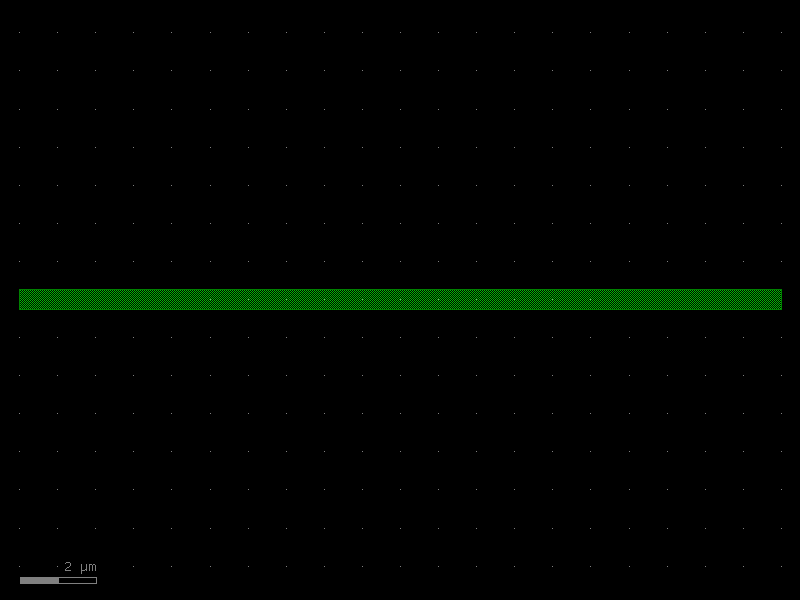

In [9]:
@kf.cell
def mzi_arm(cross_section: str, length_um: float = 20.0) -> kf.KCell:
    """A simple straight acting as an MZI arm.

    Args:
        cross_section: Name of a registered cross-section.
        length_um: Arm length in µm.
    """
    c = kf.KCell()
    xs = kf.kcl.get_icross_section(cross_section)
    length = kf.kcl.to_dbu(length_um)
    w = xs.width

    c.shapes(kf.kcl.find_layer(xs.layer)).insert(
        kf.kdb.Box(-length // 2, -w // 2, length // 2, w // 2)
    )

    c.add_port(
        port=kf.Port(
            name="o1",
            trans=kf.kdb.Trans(2, False, -length // 2, 0),  # West-facing
            cross_section=xs.base,
            kcl=kf.kcl,
        )
    )
    c.add_port(
        port=kf.Port(
            name="o2",
            trans=kf.kdb.Trans(0, False, length // 2, 0),  # East-facing
            cross_section=xs.base,
            kcl=kf.kcl,
        )
    )
    return c


arm = mzi_arm(cross_section="WG_500")
print(f"port o1 width: {arm['o1'].width} DBU = {kf.kcl.to_um(arm['o1'].width)} µm")
print(f"port o1 layer: {arm['o1'].layer}")
arm.plot()

## 8 · Cross-sections in routing

Optical and electrical routers accept a `cross_section` argument on start/end ports —
the router reads `xs.radius` and `xs.radius_min` to choose bend radii automatically.

The typical workflow:

1. Define one `DCrossSection` per waveguide type at PDK setup time.
2. Register it on `kf.kcl` with a human-readable name.
3. Pass the name (or the `CrossSection` object) wherever routers need a waveguide spec.

```python
# PDK setup (once)
xs_wg = kf.DCrossSection(kcl=kf.kcl, width=0.5, layer=L.WG,
                         sections=[(L.WGCLAD, 2.0)], radius=10.0, name="WG_500")
kf.kcl.get_icross_section(xs_wg)   # register

# In a factory function — look up by name
def my_bend(cross_section: str = "WG_500") -> kf.KCell:
    xs = kf.kcl.get_icross_section(cross_section)
    ...
```

See [Routing Overview](../routing/overview.py) for full routing examples.

## 9 · Asymmetric cross sections

`SymmetricalCrossSection` rejects odd widths (`width % 2 == 0`) and centers the
profile on the port axis. For non-symmetric profiles — angled ribs, slot
waveguides, strip-loaded waveguides, or just any odd-width strip —
`AsymmetricalCrossSection` is the way.

It describes each layer strip as a signed `[section_min, section_max]` interval
in dbu relative to the port centerline. Both bounds are integers, so edges are
always on the dbu grid regardless of width parity. The strip's width is the
derived property `section_max - section_min`.

Asymmetric cross sections live in a separate registry on `KCLayout`
(`asymmetrical_cross_sections`) and have their own getters.

In [10]:
from kfactory.exceptions import (
    AsymmetricMirrorRequiredError,
    CrossSectionSymmetryMismatchError,
)

# A 301-dbu-wide strip shifted toward +y of the port centerline.
# Width is ODD (would be rejected by SymmetricalCrossSection) and the strip is
# off-center — [-100, 201] rather than [-150, 151].
acs = kf.kcl.get_asymmetrical_cross_section(
    kf.AsymmetricalCrossSection(
        layer=L.WG,
        section_min=-100,
        section_max=201,
        name="ASYM_301",
    )
)
print(f"width:       {acs.width} DBU  (odd!)")
print(f"main strip:  [{acs.section_min}, {acs.section_max}]")
print(f"xmin/xmax:   ({acs.get_xmin()}, {acs.get_xmax()})")
print(f"is_symmetric: {acs.is_symmetric()}")

width:       301 DBU  (odd!)
main strip:  [-100, 201]
xmin/xmax:   (-100, 201)
is_symmetric: False


### Cell convention for asymmetric profiles

For an asymmetric strip to chain correctly between cells, the cell's two ports
must have matching profile orientation in cell-local coordinates. With a
straight-like cell, the standard convention is:

- `o1 = R180` at the left edge (faces -x, no mirror).
- `o2 = M0`  at the right edge (faces +x with `mirror=True`).

The mirror flag on `o2` flips the port-local frame so that "right side of
profile" maps to the same world-y direction at both ports.

o1 trans: r180 0,0  mirror=False
o2 trans: m0 5000,0  mirror=True


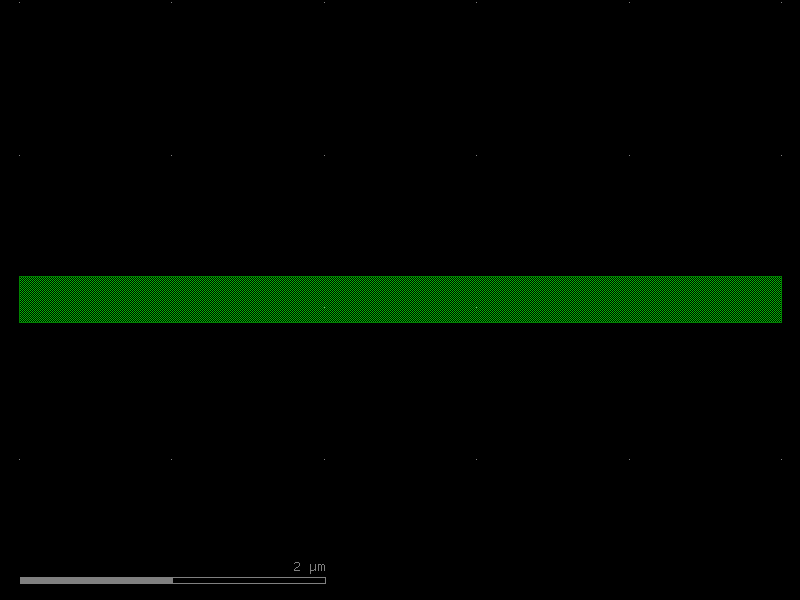

In [11]:
@kf.cell
def asym_straight(cross_section: str = "ASYM_301") -> kf.KCell:
    """Asymmetric-cross-section straight.

    Port convention:
        o1 → R180 at left, faces -x.
        o2 → M0   at right, faces +x with mirror (asymmetric requirement).
    """
    c = kf.KCell()
    xs = kf.kcl.get_asymmetrical_cross_section(cross_section)
    length = 5_000  # 5 µm
    c.shapes(kf.kcl.find_layer(xs.layer)).insert(
        kf.kdb.Box(0, xs.section_min, length, xs.section_max)
    )
    c.create_port(name="o1", trans=kf.kdb.Trans(2, False, 0, 0), cross_section=xs)
    c.create_port(name="o2", trans=kf.kdb.Trans(0, True, length, 0), cross_section=xs)
    return c


straight = asym_straight()
print(
    f"o1 trans: {straight['o1'].base.trans}  mirror={straight['o1'].base.trans.mirror}"
)
print(
    f"o2 trans: {straight['o2'].base.trans}  mirror={straight['o2'].base.trans.mirror}"
)
straight.plot()

### Chaining: `o2 → o1` works by default

Connecting `inst_b.o1` to `inst_a.o2` is the natural chain. With the port
convention above, `o2` already carries the `mirror` flag, so the join between
the two ports is an M90 (mirror) transform — exactly what an asymmetric
profile needs to keep its left/right halves aligned. `connect` does **not**
copy the other port's mirror flag onto the instance; it simply honors the
per-port frames, so the default `connect` succeeds and neither instance ends
up with a mirror flag.

kfactory validates this by requiring the two connected asymmetric ports to
have opposite mirror flags in world space. If they'd line up with the same
orientation (an R180 join, which flips the profile), it raises
`AsymmetricMirrorRequiredError`.

Default connect:
  ia.trans: r0 0,0  (mirror=False)
  ib.trans: r0 5000,0  (mirror=False)


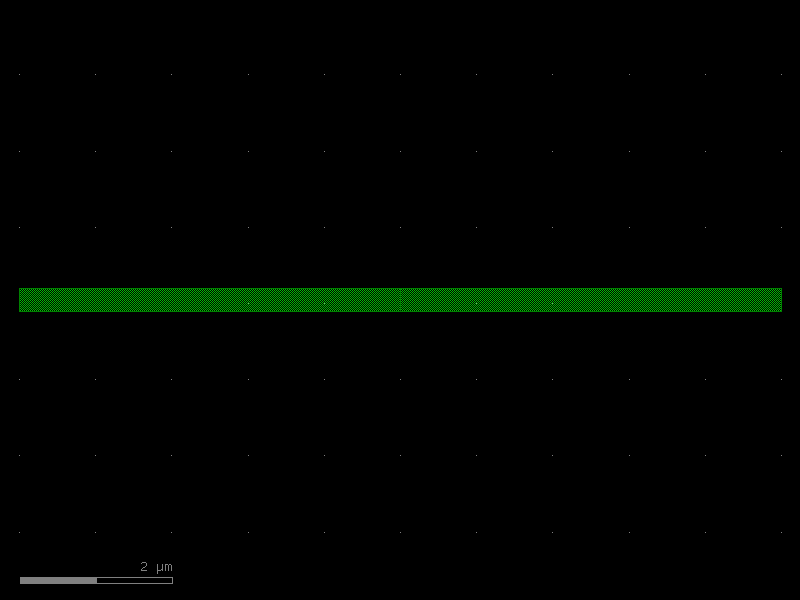

In [12]:
parent_chain = kf.KCell(name="asym_chain_ok")
ia = parent_chain << straight
ib = parent_chain << straight

# Default connect → succeeds, neither instance ends up with a mirror flag
ib.connect("o1", ia, "o2")
print("Default connect:")
print(f"  ia.trans: {ia.trans}  (mirror={ia.trans.mirror})")
print(f"  ib.trans: {ib.trans}  (mirror={ib.trans.mirror})")
parent_chain.plot()

### `o1 ↔ o1`: still possible, but one instance ends up mirrored

Connecting two of the same kind of end (both `R180`) needs `mirror=True`
too, but the result has one of the two instances flipped.

WITHOUT mirror=True, o1↔o1 raises:


  AsymmetricMirrorRequiredError: Cannot connect ports 'o1' and 'o1' carrying the same asymmetric cross section without `mirror=True`. Asymmetric profiles require an M90 transformation (mirror) — R180 would flip the left/right halves. Pass `mirror=True` to `connect`.

WITH mirror=True (one instance mirrored):
  ia2.trans: r0 0,0  (mirror=False)
  ib2.trans: m90 0,0  (mirror=True)


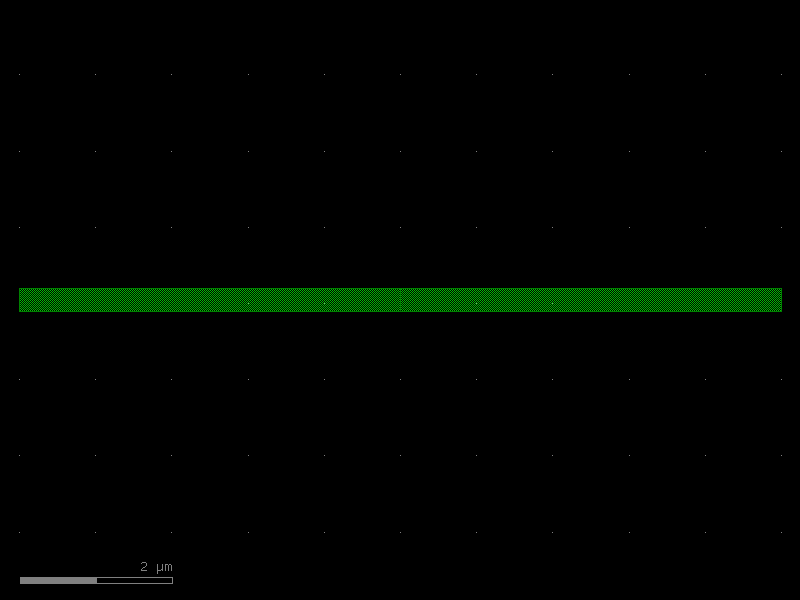

In [13]:
parent_o1o1 = kf.KCell(name="asym_chain_o1o1")
ia2 = parent_o1o1 << straight
ib2 = parent_o1o1 << straight

try:
    ib2.connect("o1", ia2, "o1")
except AsymmetricMirrorRequiredError as e:
    print("WITHOUT mirror=True, o1↔o1 raises:")
    print(f"  AsymmetricMirrorRequiredError: {e}\n")

ib2.connect("o1", ia2, "o1", mirror=True)
print("WITH mirror=True (one instance mirrored):")
print(f"  ia2.trans: {ia2.trans}  (mirror={ia2.trans.mirror})")
print(f"  ib2.trans: {ib2.trans}  (mirror={ib2.trans.mirror})")
parent_o1o1.plot()

### Connecting symmetric ↔ asymmetric: structural mismatch

A port carrying a `SymmetricalCrossSection` cannot connect to one carrying an
`AsymmetricalCrossSection` — the two are structurally different objects.
This raises `CrossSectionSymmetryMismatchError` **before** the width/layer
checks, and it's not bypassable by `allow_width_mismatch=True`.

In [14]:
@kf.cell
def sym_straight(cross_section: str = "WG_500") -> kf.KCell:
    """Plain symmetric straight for the mismatch demo."""
    c = kf.KCell()
    xs = kf.kcl.get_icross_section(cross_section)
    length = 5_000
    c.shapes(kf.kcl.find_layer(xs.layer)).insert(
        kf.kdb.Box(0, -xs.width // 2, length, xs.width // 2)
    )
    c.create_port(name="o1", trans=kf.kdb.Trans(2, False, 0, 0), cross_section=xs)
    c.create_port(name="o2", trans=kf.kdb.Trans(0, False, length, 0), cross_section=xs)
    return c


parent_mix = kf.KCell(name="asym_sym_mismatch")
sym_inst = parent_mix << sym_straight("WG_500")
asym_inst = parent_mix << straight

try:
    asym_inst.connect("o1", sym_inst, "o2")
except CrossSectionSymmetryMismatchError as e:
    print("Symmetric ↔ asymmetric connect raises:")
    print(f"  CrossSectionSymmetryMismatchError: {e}")

Symmetric ↔ asymmetric connect raises:
  CrossSectionSymmetryMismatchError: Cross section symmetry mismatch between ports 'o1' (asymmetric) and 'o2' (symmetric). Symmetric and asymmetric cross sections cannot be connected.


### Summary of asymmetric port behavior

| Scenario | Default `connect()` | `connect(mirror=True)` |
|---|---|---|
| sym ↔ sym | works | works |
| asym o2 → asym o1 (chain) | works, no instance mirrored | `AsymmetricMirrorRequiredError` |
| asym o1 ↔ asym o1 | `AsymmetricMirrorRequiredError` | works, one instance mirrored |
| sym ↔ asym | `CrossSectionSymmetryMismatchError` (not bypassable) | same error |

The check is on the **mirror flags**: kfactory requires the two connected
asymmetric ports to end up with opposite mirror orientations (an M90 join). A
natural `o2 → o1` chain already satisfies this via the port frames, so it
works by default and adding `mirror=True` would over-mirror it and raise.

## Summary

| Need | Use |
|---|---|
| Human-friendly µm API | `kf.DCrossSection(kcl, width, layer, sections, ...)` |
| DBU integer precision | `kf.CrossSection(kcl, width, layer, sections, ...)` |
| Reuse an existing enclosure | `SymmetricalCrossSection(width, enclosure)` |
| Register / look up by name | `kf.kcl.get_icross_section(name_or_spec)` |
| µm view of a registered xs | `kf.kcl.get_dcross_section(name_or_spec)` |

## See Also

| Topic | Where |
|-------|-------|
| Layer enclosures (auto-cladding) | [Enclosures: Layer Enclosure](../enclosures/layer_enclosure.py) |
| Cell-level enclosures (tiling) | [Enclosures: KCell Enclosure](../enclosures/kcell_enclosure.py) |
| Straight waveguide (uses xs) | [Components: Straight](cells/factories/straight.py) |
| Width tapers (uses xs) | [Components: Tapers](cells/factories/taper.py) |
| Routing with cross-sections | [Routing: Overview](../routing/overview.py) |